# Submission Blending

Blend multiple model submissions by weighted averaging of predicted probabilities.
Different algorithms capture different patterns — blending almost always outperforms any single model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')

IS_KAGGLE = os.path.exists('/kaggle/input')
SUB_DIR   = '/kaggle/working/' if IS_KAGGLE else '../'
DATA_DIR  = '/kaggle/input/playground-series-s6e3/' if IS_KAGGLE else '../data/'
TARGET    = 'Churn'

print(f'Submission dir: {SUB_DIR}')

Submission dir: ../


## 1. Load Submissions

Add known public scores so the blender can weight by performance.

In [2]:
# ── Register submissions with their known public LB scores ────────────────────
# Set public_score to None if unknown — those are excluded from score-weighted blend
SUBMISSIONS = [
    # ── Original models ────────────────────────────────────────────────────────
    {'file': 'submission_xgboost_tuned_multiseed_fe.csv',   'label': 'XGB-50t-FE',         'public_score': 0.91417},
    {'file': 'submission_xgboost_multiseed_fe_100_6.csv',   'label': 'XGB-100t-6fold',      'public_score': 0.91415},
    {'file': 'submission_lightgbm_100n.csv',                'label': 'LGB-100n',            'public_score': None},
    {'file': 'submission_xgboost_100n.csv',                 'label': 'XGB-100n',            'public_score': None},
    {'file': 'submission_catboost_tuned_multiseed_fe.csv',  'label': 'CatBoost',            'public_score': 0.91340},
    # ── nb10: XGB scaledpos + lossguide (NEW BEST) ────────────────────────────
    {'file': 'submission_xgb_scaledpos_blend.csv',          'label': 'XGB-sp-blend',        'public_score': 0.91445},
    {'file': 'submission_xgb_scaledpos_ensemble.csv',       'label': 'XGB-sp-ens',          'public_score': 0.91444},
    {'file': 'submission_xgb_scaledpos_fulldata.csv',       'label': 'XGB-sp-full',         'public_score': 0.91438},
]

subs = {}
for s in SUBMISSIONS:
    path = os.path.join(SUB_DIR, s['file'])
    if os.path.exists(path):
        df = pd.read_csv(path)
        subs[s['label']] = {'preds': df[TARGET].values, 'ids': df['id'].values,
                            'score': s['public_score'], 'file': s['file']}
        score_str = f"{s['public_score']:.5f}" if s['public_score'] else 'unknown'
        print(f"  Loaded : {s['label']:25s} | LB: {score_str}")
    else:
        print(f"  MISSING: {s['file']}")

# Use IDs from first loaded submission as reference
ref_ids = next(iter(subs.values()))['ids']
print(f'\n{len(subs)} submissions loaded, {len(ref_ids):,} rows each.')

  Loaded : XGB-50t-FE                | LB: 0.91417
  Loaded : XGB-100t-6fold            | LB: 0.91415
  Loaded : LGB-100n                  | LB: unknown
  Loaded : XGB-100n                  | LB: unknown
  Loaded : CatBoost                  | LB: 0.91340
  Loaded : XGB-sp-blend              | LB: 0.91445
  Loaded : XGB-sp-ens                | LB: 0.91444
  Loaded : XGB-sp-full               | LB: 0.91438

8 submissions loaded, 254,655 rows each.


## 2. Prediction Distribution

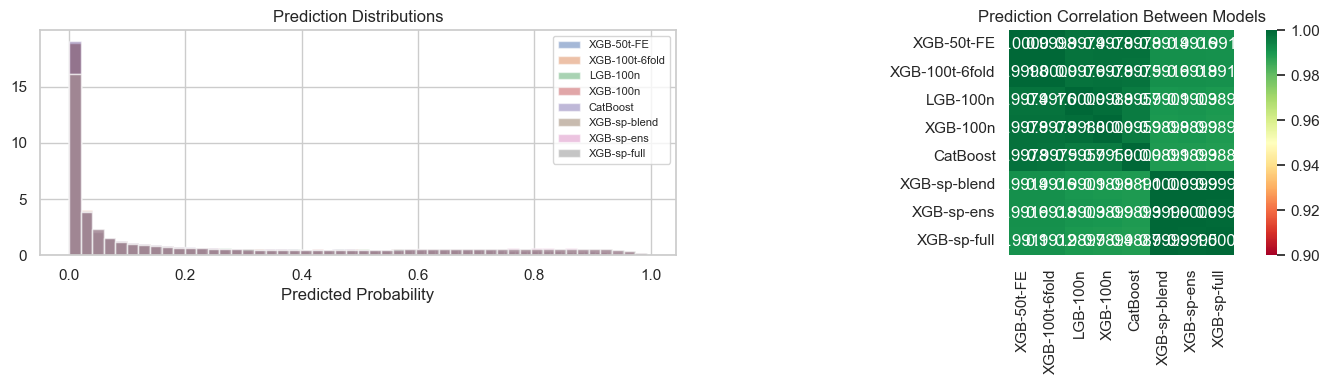


Prediction stats:
        XGB-50t-FE  XGB-100t-6fold     LGB-100n     XGB-100n     CatBoost  \
count  254655.0000     254655.0000  254655.0000  254655.0000  254655.0000   
mean        0.2181          0.2181       0.2182       0.2182       0.2181   
std         0.2762          0.2760       0.2759       0.2760       0.2757   
min         0.0001          0.0001       0.0000       0.0001       0.0002   
25%         0.0063          0.0063       0.0062       0.0062       0.0060   
50%         0.0624          0.0624       0.0635       0.0634       0.0643   
75%         0.3917          0.3915       0.3917       0.3918       0.3911   
max         0.9890          0.9885       0.9927       0.9927       0.9839   

       XGB-sp-blend   XGB-sp-ens  XGB-sp-full  
count   254655.0000  254655.0000  254655.0000  
mean         0.2710       0.2710       0.2710  
std          0.3113       0.3112       0.3114  
min          0.0001       0.0002       0.0001  
25%          0.0107       0.0107       0.0106  

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of raw predictions
for label, data in subs.items():
    axes[0].hist(data['preds'], bins=50, alpha=0.5, label=label, density=True)
axes[0].set_title('Prediction Distributions')
axes[0].set_xlabel('Predicted Probability')
axes[0].legend(fontsize=8)

# Pairwise correlation between model predictions
pred_df = pd.DataFrame({label: data['preds'] for label, data in subs.items()})
corr = pred_df.corr()
sns.heatmap(corr, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0.9, vmax=1.0,
            ax=axes[1], square=True)
axes[1].set_title('Prediction Correlation Between Models')

plt.tight_layout()
plt.show()

print('\nPrediction stats:')
print(pred_df.describe().round(4))

## 3. Blend Strategies

Three approaches:
- **Equal weight** — simple average of all models
- **Score-weighted** — weight proportional to public LB score (models with known scores only)
- **Custom weight** — manually set weights in the CONFIG below

In [4]:
# ── Three-way blend CONFIG ─────────────────────────────────────────────────────
# Three model families:
#   A) XGB-scaledpos (nb10)  → best single model, lossguide+scale_pos_weight
#   B) XGB-FE originals      → established strong multi-seed ensemble
#   C) LGB-100n              → different algorithm = diversity
#
# Weights are normalised automatically. Set 0.0 to exclude a model.

BLEND_CONFIGS = {

    # v1 — Heavy on scaledpos (best single), equal XGB+LGB diversity
    'threeway_v1': {
        'XGB-sp-blend':    3.0,   # nb10 best (0.91445)
        'XGB-50t-FE':      2.0,   # original XGB best (0.91417)
        'XGB-100t-6fold':  2.0,   # original XGB (0.91415)
        'LGB-100n':        2.0,   # LGB diversity
        'XGB-sp-ens':      0.0,
        'XGB-sp-full':     0.0,
        'XGB-100n':        0.0,
        'CatBoost':        0.0,
    },

    # v2 — Boost LGB diversity, slightly less on old XGB
    'threeway_v2': {
        'XGB-sp-blend':    3.0,   # nb10 best
        'XGB-50t-FE':      1.5,
        'XGB-100t-6fold':  1.5,
        'LGB-100n':        3.0,   # emphasise LGB for more diversity
        'XGB-sp-ens':      0.0,
        'XGB-sp-full':     0.0,
        'XGB-100n':        0.0,
        'CatBoost':        0.0,
    },

    # v3 — Use both nb10 XGB variants + LGB (max diversity within nb10)
    'threeway_v3': {
        'XGB-sp-blend':    2.0,   # nb10 best
        'XGB-sp-ens':      1.0,   # nb10 ensemble (slightly different from blend)
        'XGB-50t-FE':      1.5,
        'XGB-100t-6fold':  1.5,
        'LGB-100n':        2.0,
        'XGB-sp-full':     0.0,
        'XGB-100n':        0.0,
        'CatBoost':        0.0,
    },

    # v4 — Pure two-way: nb10 best vs old blend best (no LGB — test if LGB helps)
    'twoway_sp_vs_xgb': {
        'XGB-sp-blend':    1.0,   # nb10 best (0.91445)
        'XGB-50t-FE':      1.0,   # original best (0.91417)
        'XGB-100t-6fold':  1.0,
        'LGB-100n':        0.0,
        'XGB-sp-ens':      0.0,
        'XGB-sp-full':     0.0,
        'XGB-100n':        0.0,
        'CatBoost':        0.0,
    },

    # v5 — Original best blend (kept for reference)
    'original_best': {
        'XGB-50t-FE':      2.0,
        'XGB-100t-6fold':  2.0,
        'LGB-100n':        1.5,
        'XGB-100n':        1.0,
        'XGB-sp-blend':    0.0,
        'XGB-sp-ens':      0.0,
        'XGB-sp-full':     0.0,
        'CatBoost':        0.0,
    },
}

# Default for single-blend cells below
CUSTOM_WEIGHTS = BLEND_CONFIGS['threeway_v1']

print("Blend configs defined:")
for name, weights in BLEND_CONFIGS.items():
    active = {k: v for k, v in weights.items() if v > 0}
    print(f"  {name:25s} → {active}")

Blend configs defined:
  threeway_v1               → {'XGB-sp-blend': 3.0, 'XGB-50t-FE': 2.0, 'XGB-100t-6fold': 2.0, 'LGB-100n': 2.0}
  threeway_v2               → {'XGB-sp-blend': 3.0, 'XGB-50t-FE': 1.5, 'XGB-100t-6fold': 1.5, 'LGB-100n': 3.0}
  threeway_v3               → {'XGB-sp-blend': 2.0, 'XGB-sp-ens': 1.0, 'XGB-50t-FE': 1.5, 'XGB-100t-6fold': 1.5, 'LGB-100n': 2.0}
  twoway_sp_vs_xgb          → {'XGB-sp-blend': 1.0, 'XGB-50t-FE': 1.0, 'XGB-100t-6fold': 1.0}
  original_best             → {'XGB-50t-FE': 2.0, 'XGB-100t-6fold': 2.0, 'LGB-100n': 1.5, 'XGB-100n': 1.0}


In [5]:
def blend(subs_dict, weights):
    """Weighted average of predictions. Weights normalised to sum=1."""
    total_weight = sum(weights.values())
    blended = np.zeros(len(ref_ids))
    for label, w in weights.items():
        if label in subs_dict and w > 0:
            blended += (w / total_weight) * subs_dict[label]['preds']
    return blended

# ── Equal weight ──────────────────────────────────────────────────────────────
equal_w    = {label: 1.0 for label in subs}
equal_pred = blend(subs, equal_w)

# ── Score-weighted (known scores only) ───────────────────────────────────────
scored = {label: data for label, data in subs.items() if data['score'] is not None}
score_w    = {label: data['score'] for label, data in scored.items()}
score_pred = blend(subs, score_w)

# ── Custom weight ─────────────────────────────────────────────────────────────
custom_pred = blend(subs, CUSTOM_WEIGHTS)

blends = {
    'Equal':         equal_pred,
    'Score-weighted': score_pred,
    'Custom':        custom_pred,
}

print('Blend summary:')
for name, preds in blends.items():
    print(f"  {name:20s} | mean={preds.mean():.4f}  std={preds.std():.4f}  "
          f"min={preds.min():.4f}  max={preds.max():.4f}")

# Correlation between blend strategies
blend_df = pd.DataFrame(blends)
print('\nCorrelation between blend strategies:')
print(blend_df.corr().round(6))

Blend summary:
  Equal                | mean=0.2380  std=0.2885  min=0.0001  max=0.9903
  Score-weighted       | mean=0.2445  std=0.2929  min=0.0001  max=0.9897
  Custom               | mean=0.2357  std=0.2871  min=0.0001  max=0.9907

Correlation between blend strategies:
                   Equal  Score-weighted    Custom
Equal           1.000000        0.999771  0.999942
Score-weighted  0.999771        1.000000  0.999645
Custom          0.999942        0.999645  1.000000


## 4. Rank Averaging (Optional)

Converts each model's predictions to percentile ranks before averaging.
Reduces the influence of outlier probability values and often improves calibration.

In [6]:
from scipy.stats import rankdata

def rank_average(subs_dict, weights):
    """Rank-transform each model's predictions then weighted average."""
    n = len(ref_ids)
    total_weight = sum(weights.values())
    blended = np.zeros(n)
    for label, w in weights.items():
        if label in subs_dict and w > 0:
            ranks = rankdata(subs_dict[label]['preds']) / n
            blended += (w / total_weight) * ranks
    return blended

rank_pred = rank_average(subs, CUSTOM_WEIGHTS)
blends['Custom-Rank'] = rank_pred

print(f"Rank-avg | mean={rank_pred.mean():.4f}  std={rank_pred.std():.4f}")

Rank-avg | mean=0.5000  std=0.2885


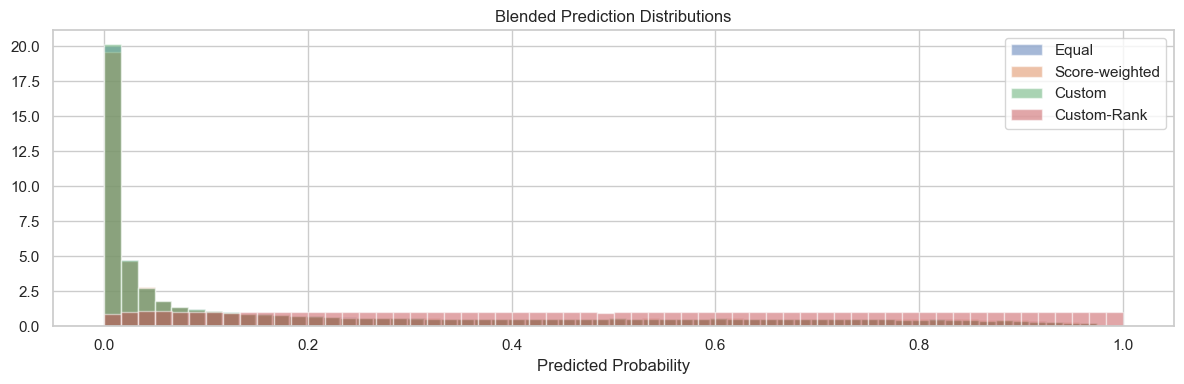

In [7]:
# Visual comparison of all blend outputs
fig, ax = plt.subplots(figsize=(12, 4))
for name, preds in blends.items():
    ax.hist(preds, bins=60, alpha=0.5, label=name, density=True)
ax.set_title('Blended Prediction Distributions')
ax.set_xlabel('Predicted Probability')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Save All Blend Submissions

In [8]:
from scipy.stats import rankdata

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
n = len(ref_ids)

saved = []
print(f"{'Config':25s} | {'Type':10s} | Range")
print("-" * 60)

for config_name, weights in BLEND_CONFIGS.items():

    # ── Weighted average blend ────────────────────────────────────────────────
    total_w = sum(w for w in weights.values() if w > 0)
    blended = np.zeros(n)
    for label, w in weights.items():
        if label in subs and w > 0:
            blended += (w / total_w) * subs[label]['preds']

    # ── Rank-averaged blend ───────────────────────────────────────────────────
    rank_blended = np.zeros(n)
    for label, w in weights.items():
        if label in subs and w > 0:
            ranks = rankdata(subs[label]['preds']) / n
            rank_blended += (w / total_w) * ranks

    # ── Save both ─────────────────────────────────────────────────────────────
    for blend_type, preds in [('prob', blended), ('rank', rank_blended)]:
        fname = f"submission_blend_{config_name}_{blend_type}.csv"
        out = sample_sub.copy()
        out[TARGET] = preds
        out.to_csv(os.path.join(SUB_DIR, fname), index=False)
        saved.append(fname)
        print(f"  {config_name:25s} | {blend_type:10s} | [{preds.min():.4f}, {preds.max():.4f}]  → {fname}")

print(f"\n{len(saved)} blend files saved.")

Config                    | Type       | Range
------------------------------------------------------------


  threeway_v1               | prob       | [0.0001, 0.9907]  → submission_blend_threeway_v1_prob.csv
  threeway_v1               | rank       | [0.0000, 1.0000]  → submission_blend_threeway_v1_rank.csv


  threeway_v2               | prob       | [0.0001, 0.9911]  → submission_blend_threeway_v2_prob.csv
  threeway_v2               | rank       | [0.0000, 1.0000]  → submission_blend_threeway_v2_rank.csv


  threeway_v3               | prob       | [0.0001, 0.9909]  → submission_blend_threeway_v3_prob.csv
  threeway_v3               | rank       | [0.0000, 1.0000]  → submission_blend_threeway_v3_rank.csv


  twoway_sp_vs_xgb          | prob       | [0.0001, 0.9900]  → submission_blend_twoway_sp_vs_xgb_prob.csv
  twoway_sp_vs_xgb          | rank       | [0.0000, 1.0000]  → submission_blend_twoway_sp_vs_xgb_rank.csv


  original_best             | prob       | [0.0001, 0.9901]  → submission_blend_original_best_prob.csv
  original_best             | rank       | [0.0000, 1.0000]  → submission_blend_original_best_rank.csv

10 blend files saved.
